# Strategy Return & Decay Analysis - Focused Component Testing

This notebook analyzes the strategy lifecycle component in isolation, focusing on:
- Return distribution of newly created strategies
- Natural decay mechanics over time
- Population-level distribution evolution

**All parameters are pulled from `strategy_parameters.py` and leverage existing `Strategy` and `StrategyFactory` classes.**

## Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import copy

# Add parent directory to path
sys.path.insert(0, os.path.abspath('../..'))

# Import existing components (leverage existing code!)
from components.strategy_lifecycle.strategy_factory import StrategyFactory
from components.strategy_lifecycle.strategy import Strategy
from components.strategy_lifecycle.strategy_parameters import StrategyParameters as SP
from components.author_collaboration.author_factory import AuthorFactory

print("✅ Imports successful")
print(f"\nCurrent parameters from strategy_parameters.py:")
print(f"  Return decay rate: {SP.STRATEGY_RETURN_DECAY_RATE*100}% per quarter")
print(f"  Min active return: {SP.STRATEGY_MIN_ACTIVE_RETURN}%")
print(f"  Max expected return cap: {SP.STRATEGY_MAX_EXPECTED_RETURN}%")
print(f"  Return improvement factor: {SP.STRATEGY_RETURN_IMPROVEMENT_FACTOR*100}%")
print(f"\n  Distribution mix:")
print(f"    T-distribution: {SP.STRATEGY_T_DISTRIBUTION_PROB*100}%")
print(f"    Uniform distribution: {SP.STRATEGY_UNIFORM_DISTRIBUTION_PROB*100}%")
print(f"\n  T-distribution return range: {SP.T_DISTRIBUTION_LOC_MIN}% - {SP.T_DISTRIBUTION_LOC_MAX}%")
print(f"  Uniform distribution return range: {SP.UNIFORM_DISTRIBUTION_LOC_MIN}% - {SP.UNIFORM_DISTRIBUTION_LOC_MAX + SP.UNIFORM_DISTRIBUTION_SCALE_MAX}%")

✅ Imports successful

Current parameters from strategy_parameters.py:
  Return decay rate: 3.0% per quarter
  Min active return: 0.0%
  Max expected return cap: 5.0%
  Return improvement factor: 10.0%

  Distribution mix:
    T-distribution: 90.0%
    Uniform distribution: 10.0%

  T-distribution return range: 2.0% - 5.0%
  Uniform distribution return range: -1.0% - 6.0%


## Analysis 1: New Strategy Return Distribution

**Key Question:** What is the distribution of expected returns for newly created strategies?

This shows the initial return profile before any decay or improvements are applied.

In [2]:
# Create a dummy author for strategy generation
dummy_authors = AuthorFactory.create_test_author_pool(1, hire_quarter=0)

# Generate 100 new strategies
num_strategies = 100
new_strategies = []

for i in range(num_strategies):
    strategy = StrategyFactory.create_new_strategy(
        authors=dummy_authors,
        quarter=0,
        strategy_id=f"strat_{i}"
    )
    new_strategies.append(strategy)

# Extract expected returns
expected_returns = [s.get_expected_return() for s in new_strategies]

# Statistics
print(f"📊 New Strategy Return Distribution (n={num_strategies})")
print(f"="*70)
print(f"Mean expected return: {np.mean(expected_returns):.2f}%")
print(f"Median expected return: {np.median(expected_returns):.2f}%")
print(f"Std deviation: {np.std(expected_returns):.2f}%")
print(f"Min/Max: {np.min(expected_returns):.2f}% / {np.max(expected_returns):.2f}%")
print(f"\nDistribution types:")
t_count = sum(1 for s in new_strategies if s.distribution_type == 't')
uniform_count = sum(1 for s in new_strategies if s.distribution_type == 'uniform')
print(f"  T-distribution: {t_count} ({t_count/num_strategies*100:.0f}%)")
print(f"  Uniform distribution: {uniform_count} ({uniform_count/num_strategies*100:.0f}%)")

📊 New Strategy Return Distribution (n=100)
Mean expected return: 3.33%
Median expected return: 3.38%
Std deviation: 0.94%
Min/Max: 0.85% / 4.93%

Distribution types:
  T-distribution: 94 (94%)
  Uniform distribution: 6 (6%)


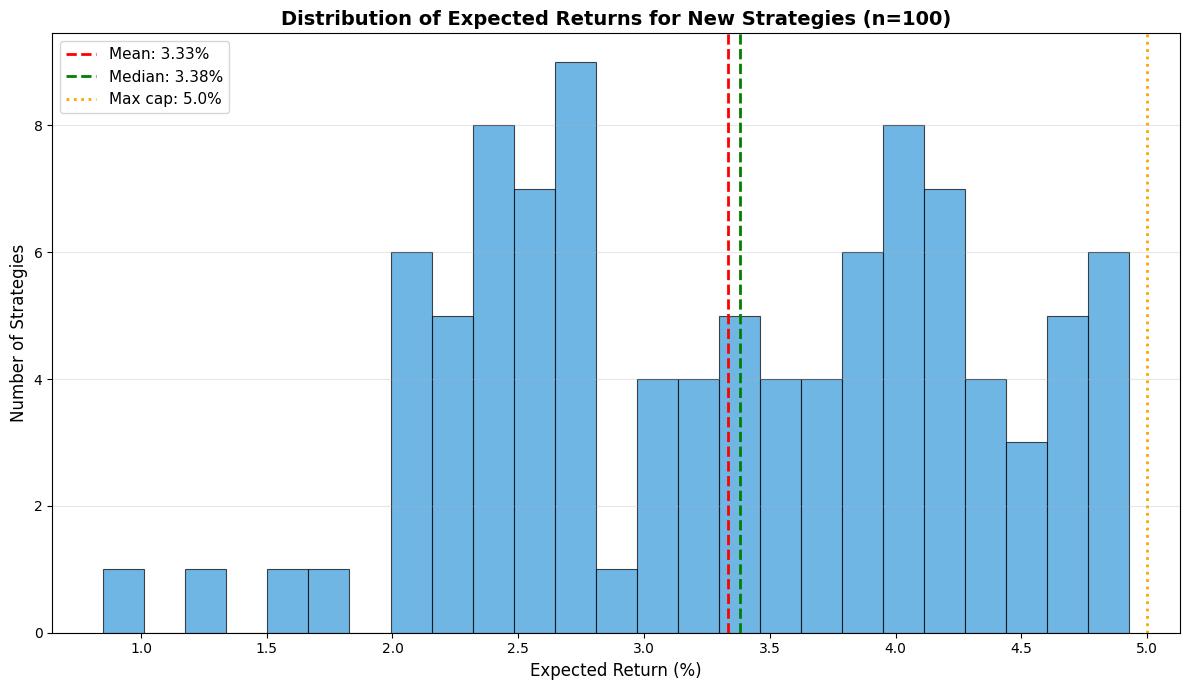


💡 Key Insight:
New strategies are initialized with expected returns ranging from 0.85% to 4.93%.
The distribution reflects the configured mix: 90% T-distribution, 10% uniform.


In [3]:
# Plot histogram
fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(expected_returns, bins=25, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.8)
ax.axvline(x=np.mean(expected_returns), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(expected_returns):.2f}%')
ax.axvline(x=np.median(expected_returns), color='green', linestyle='--', linewidth=2,
           label=f'Median: {np.median(expected_returns):.2f}%')
ax.axvline(x=SP.STRATEGY_MAX_EXPECTED_RETURN, color='orange', linestyle=':', linewidth=2,
           label=f'Max cap: {SP.STRATEGY_MAX_EXPECTED_RETURN}%')

ax.set_xlabel('Expected Return (%)', fontsize=12)
ax.set_ylabel('Number of Strategies', fontsize=12)
ax.set_title(f'Distribution of Expected Returns for New Strategies (n={num_strategies})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight:")
print(f"New strategies are initialized with expected returns ranging from {np.min(expected_returns):.2f}% to {np.max(expected_returns):.2f}%.")
print(f"The distribution reflects the configured mix: {SP.STRATEGY_T_DISTRIBUTION_PROB*100:.0f}% T-distribution, {SP.STRATEGY_UNIFORM_DISTRIBUTION_PROB*100:.0f}% uniform.")

## Analysis 2: Single Strategy Decay Trajectory

**Key Question:** How does a single strategy's expected return decay over time?

This demonstrates the dynamic decay mechanism where decay rate varies with current expected return.

In [4]:
# Create a strategy with exactly 5% expected return
test_strategy = StrategyFactory.create_new_strategy(
    authors=dummy_authors,
    quarter=0,
    strategy_id="decay_test"
)

# Manually set to exactly 5% for clean demonstration
test_strategy.distribution_loc = 5.0
test_strategy._create_distribution()

print(f"📊 Strategy Decay Simulation")
print(f"="*70)
print(f"Initial expected return: {test_strategy.get_expected_return():.2f}%")
print(f"Decay rate: {SP.STRATEGY_RETURN_DECAY_RATE*100}% per quarter")
print(f"Death threshold: {SP.STRATEGY_MIN_ACTIVE_RETURN}%")
print(f"\nSimulating 30 quarters...\n")

# Track decay over 30 quarters
num_quarters = 30
quarters = list(range(num_quarters + 1))
returns_over_time = [test_strategy.get_expected_return()]

for quarter in range(1, num_quarters + 1):
    test_strategy.apply_natural_decay()
    returns_over_time.append(test_strategy.get_expected_return())
    
    if quarter <= 10 or quarter % 5 == 0:
        status = "🟢 Active" if test_strategy.is_active else "🔴 Inactive"
        print(f"Q{quarter:2d}: {returns_over_time[-1]:6.3f}%  {status}")

# Find when strategy died
death_quarter = next((i for i, r in enumerate(returns_over_time) if r < SP.STRATEGY_MIN_ACTIVE_RETURN), None)
if death_quarter:
    print(f"\n⚠️  Strategy became inactive at Q{death_quarter} (return: {returns_over_time[death_quarter]:.3f}%)")
else:
    print(f"\n✅ Strategy still active at Q{num_quarters} (return: {returns_over_time[-1]:.3f}%)")

📊 Strategy Decay Simulation
Initial expected return: 5.00%
Decay rate: 3.0% per quarter
Death threshold: 0.0%

Simulating 30 quarters...

Q 1:  4.850%  🟢 Active
Q 2:  4.709%  🟢 Active
Q 3:  4.576%  🟢 Active
Q 4:  4.450%  🟢 Active
Q 5:  4.331%  🟢 Active
Q 6:  4.219%  🟢 Active
Q 7:  4.112%  🟢 Active
Q 8:  4.011%  🟢 Active
Q 9:  3.914%  🟢 Active
Q10:  3.822%  🟢 Active
Q15:  3.421%  🟢 Active
Q20:  3.097%  🟢 Active
Q25:  2.829%  🟢 Active
Q30:  2.604%  🟢 Active

✅ Strategy still active at Q30 (return: 2.604%)


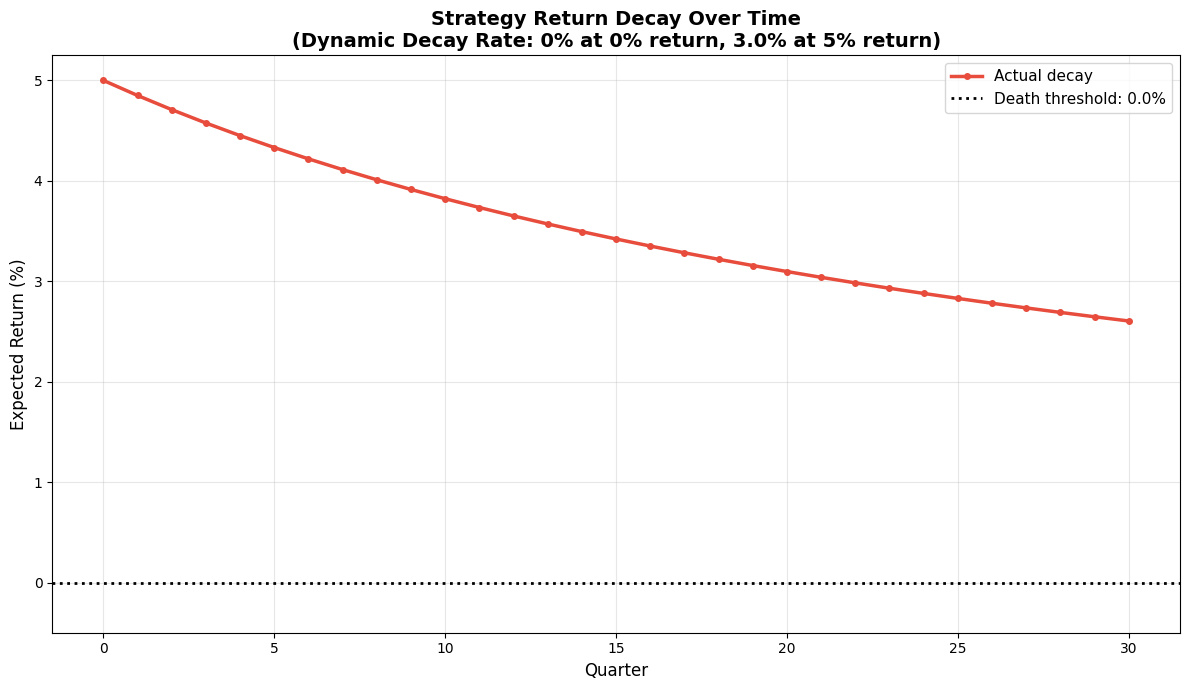


💡 Key Insight:
The decay rate is dynamic: good strategies (5% return) decay at 3.0%, bad strategies (0% return) decay at 0%.
Decay rate = 3.0% × (current_return / 5.0%)


In [5]:
# Plot decay trajectory
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(quarters, returns_over_time, linewidth=2.5, color='#e74c3c', marker='o', 
        markersize=4, label='Actual decay')

# Death threshold
ax.axhline(y=SP.STRATEGY_MIN_ACTIVE_RETURN, color='black', linestyle=':', linewidth=2,
           label=f'Death threshold: {SP.STRATEGY_MIN_ACTIVE_RETURN}%')

# Mark death point if it occurred
if death_quarter and death_quarter < len(returns_over_time):
    ax.scatter([death_quarter], [returns_over_time[death_quarter]], 
               color='red', s=200, marker='X', zorder=5, label=f'Death at Q{death_quarter}')

ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Expected Return (%)', fontsize=12)
ax.set_title(f'Strategy Return Decay Over Time\n(Dynamic Decay Rate: 0% at 0% return, {SP.STRATEGY_RETURN_DECAY_RATE*100}% at 5% return)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.5)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight:")
print(f"The decay rate is dynamic: good strategies (5% return) decay at {SP.STRATEGY_RETURN_DECAY_RATE*100}%, bad strategies (0% return) decay at 0%.")
print(f"Decay rate = {SP.STRATEGY_RETURN_DECAY_RATE*100}% × (current_return / 5.0%)")
if death_quarter:
    print(f"A 5% strategy survives for ~{death_quarter} quarters before becoming inactive.")

## Analysis 3: Population Distribution Shift Over Time

**Key Question:** How does the entire distribution of strategy returns evolve as a population ages?

This shows how the return distribution compresses and shifts downward over time.

In [6]:
# Generate 100 fresh strategies for population analysis
num_strategies_pop = 100
population_strategies = []

for i in range(num_strategies_pop):
    strategy = StrategyFactory.create_new_strategy(
        authors=dummy_authors,
        quarter=0,
        strategy_id=f"pop_{i}"
    )
    population_strategies.append(strategy)

# Define snapshot quarters
snapshot_quarters = [0, 5, 10, 20, 40]
return_distributions = {q: [] for q in snapshot_quarters}

# Record Q0
return_distributions[0] = [s.get_expected_return() for s in population_strategies]

print(f"📊 Population Distribution Evolution (n={num_strategies_pop})")
print(f"="*70)
print(f"Snapshots at: Q{snapshot_quarters}")
print(f"\nApplying decay and recording distributions...\n")

# Simulate and record at snapshot points
for quarter in range(1, max(snapshot_quarters) + 1):
    # Apply decay
    for strategy in population_strategies:
        if strategy.is_active:
            strategy.apply_natural_decay()
    
    # Record if this is a snapshot quarter
    if quarter in snapshot_quarters:
        returns = [s.get_expected_return() for s in population_strategies if s.is_active]
        return_distributions[quarter] = returns
        
        active_count = len(returns)
        mean_return = np.mean(returns) if returns else 0
        print(f"Q{quarter:2d}: {active_count:3d} active, mean return: {mean_return:5.2f}%")

print(f"\n📈 Distribution Statistics:")
for quarter in snapshot_quarters:
    returns = return_distributions[quarter]
    if returns:
        print(f"\nQ{quarter:2d}: n={len(returns):3d}, mean={np.mean(returns):5.2f}%, "
              f"std={np.std(returns):5.2f}%, range=[{np.min(returns):5.2f}%, {np.max(returns):5.2f}%]")

📊 Population Distribution Evolution (n=100)
Snapshots at: Q[0, 5, 10, 20, 40]

Applying decay and recording distributions...

Q 5: 100 active, mean return:  2.97%
Q10: 100 active, mean return:  2.71%
Q20: 100 active, mean return:  2.30%
Q40: 100 active, mean return:  1.78%

📈 Distribution Statistics:

Q 0: n=100, mean= 3.30%, std= 1.01%, range=[ 0.98%,  5.00%]

Q 5: n=100, mean= 2.97%, std= 0.84%, range=[ 0.95%,  4.33%]

Q10: n=100, mean= 2.71%, std= 0.71%, range=[ 0.93%,  3.82%]

Q20: n=100, mean= 2.30%, std= 0.53%, range=[ 0.88%,  3.10%]

Q40: n=100, mean= 1.78%, std= 0.33%, range=[ 0.79%,  2.25%]


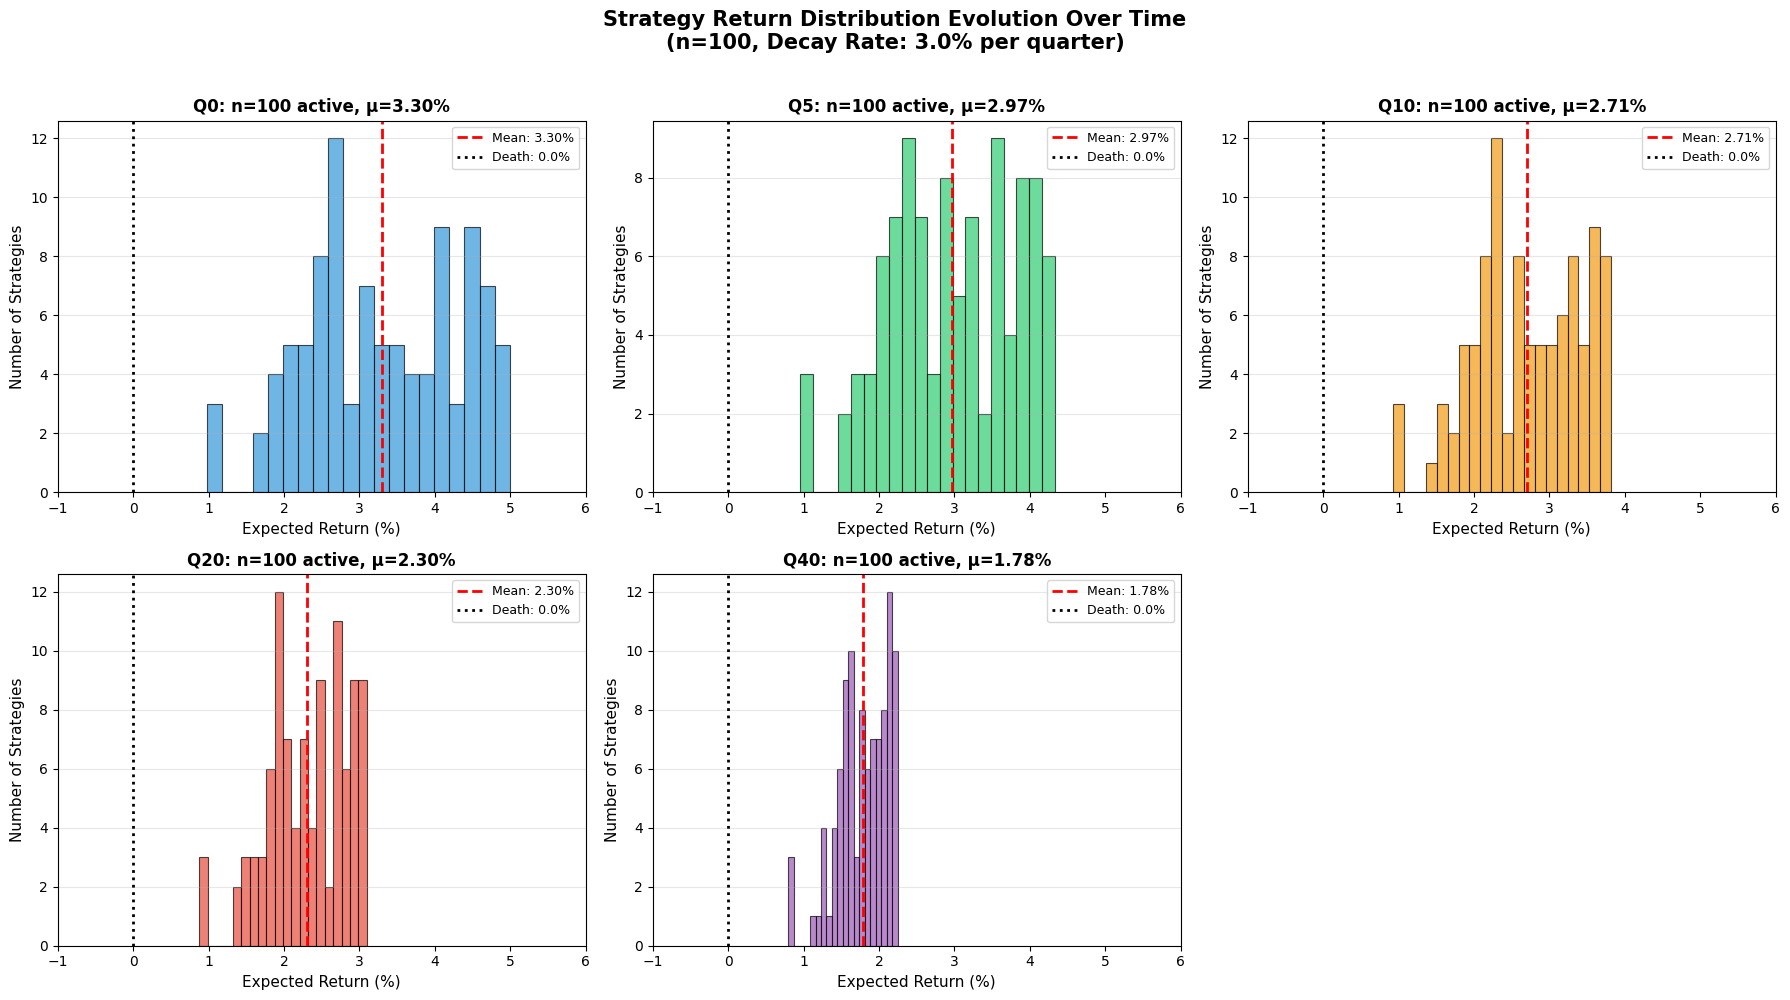


💡 Key Insights:
• The distribution shifts leftward (lower returns) as decay accumulates.
• The distribution compresses as strategies approach the death threshold.
• Strategies with higher initial returns survive longer, creating right-skew in later quarters.


In [7]:
# Plot distribution evolution as subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for idx, quarter in enumerate(snapshot_quarters):
    ax = axes[idx]
    returns = return_distributions[quarter]
    
    if returns:
        ax.hist(returns, bins=20, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.8)
        ax.axvline(x=np.mean(returns), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(returns):.2f}%')
        ax.axvline(x=SP.STRATEGY_MIN_ACTIVE_RETURN, color='black', linestyle=':', linewidth=2,
                   label=f'Death: {SP.STRATEGY_MIN_ACTIVE_RETURN}%')
        
        ax.set_xlabel('Expected Return (%)', fontsize=11)
        ax.set_ylabel('Number of Strategies', fontsize=11)
        ax.set_title(f'Q{quarter}: n={len(returns)} active, μ={np.mean(returns):.2f}%',
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim(-1, 6)
    else:
        ax.text(0.5, 0.5, 'All strategies inactive', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Q{quarter}: No active strategies', fontsize=12, fontweight='bold')

# Hide the 6th subplot
axes[5].set_visible(False)

fig.suptitle(f'Strategy Return Distribution Evolution Over Time\n(n={num_strategies_pop}, Decay Rate: {SP.STRATEGY_RETURN_DECAY_RATE*100}% per quarter)',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print(f"\n💡 Key Insights:")
print(f"• The distribution shifts leftward (lower returns) as decay accumulates.")
print(f"• The distribution compresses as strategies approach the death threshold.")
print(f"• Strategies with higher initial returns survive longer, creating right-skew in later quarters.")